# Arousal Overlap with Sleep Stages

This notebook calculates the total time that the GT arousals overlap with predicted sleep stages at various frequencies.

## Overview

Arousals are brief awakenings during sleep that disrupt sleep architecture. This notebook
tests whether the overlap between arousals and Wake annotations increases with higher
annotation frequencies. This would indicate that arousals can be better represented/captured
by high-frequency sleep staging.

## Method

1. **Load ground truth arousals** from MASS dataset annotation files (EDF format)
   - Uses timing offsets from `mass_offsets.py` to align annotations with trimmed PSG data

2. **Load sleep stage predictions** from high-frequency model sweep
   - Multiple temporal resolutions evaluated (1-3840 predictions per 30s epoch)

3. **Calculate overlap between GT arousals and predicted sleep stages** for different sleep stage frequencies

## Outputs

- `dict` of overlap durations for each model -> sleep stage frequency -> sleep stage, which is copied to `hf_scores.py`

## Dependencies

- High-frequency prediction files from `predict-high-freq.py` sweep

In [1]:
import glob
from os.path import dirname

import matplotlib.pyplot as plt
import mne
import numpy as np

from scripts.arousals.mass_offsets import offsets


def load_arousals(ann_file):
    # <Event channel="EEG C4-LER" groupName="MicroArousal" name="CARSM expert" scoringType="expert"/>
    data = mne.io.read_raw_edf(ann_file, verbose=False)
    s_id = ann_file.split("/")[-1].split(" ")[0]
    arousals = [
        (ann["onset"], ann["onset"] + ann["duration"])
        for ann in data.annotations
        if "MicroArousal" in ann["description"]
    ]
    channels = [
        ann["description"][ann["description"].find("channel") + 9:ann["description"].find("groupName") - 2]
        for ann in data.annotations
        if "MicroArousal" in ann["description"]
    ]
    # print(np.unique(channels, return_counts=True))
    if len(arousals) == 0:
        return arousals
    arousals = np.array([list(ar) + [ch] for ar, ch in zip(arousals, channels) if ch.startswith("EEG")])
    arousals[:, :2] = arousals[:, :2].astype(float) - offsets[f"mass-c{s_id.split('-')[1][1]}"][s_id]
    return arousals


def load_hf_sleep_stages(sweep_folder):
    labels_glob = f"{sweep_folder}/*/labels.npz"
    preds_glob = f"{sweep_folder}/*/predictions.npz"
    labels_files = sorted(glob.glob(labels_glob), key=lambda x: int(x.split("/")[-2]))
    preds_files = sorted(glob.glob(preds_glob), key=lambda x: int(x.split("/")[-2]))

    labels_per_sr_per_model = {}
    preds_per_sr_per_model = {}
    for label_file, pred_file in zip(labels_files, preds_files):
        with open(dirname(label_file) + "/predict-high-freq.log") as f:
            lines = f.readlines()
            sr_line = [line for line in lines if "sleep_stage_frequency" in line][0]
            sleep_stage_sr = int(sr_line.split("=")[1])
            model_line = [line for line in lines if "model.path" in line][0]
            model = model_line.split("=")[1].strip()

        if model not in labels_per_sr_per_model:
            labels_per_sr_per_model[model] = {}
            preds_per_sr_per_model[model] = {}
        labels_per_sr_per_model[model][sleep_stage_sr] = np.load(label_file)
        preds_per_sr_per_model[model][sleep_stage_sr] = np.load(pred_file)

    return labels_per_sr_per_model, preds_per_sr_per_model


def get_arousals_per_ss(arousals, sleep_stages, ss_sr, verbose=False):
    arousal_time_by_stage = [0] * 5
    epoch_duration = 30 / ss_sr
    for arousal_start, arousal_end, _ in arousals:
        arousal_start = float(arousal_start)
        arousal_end = float(arousal_end)
        # Determine which epochs the arousal overlaps with
        start_epoch = int(arousal_start // epoch_duration)
        end_epoch = int(arousal_end // epoch_duration)

        for epoch in range(start_epoch, end_epoch + 1):
            if epoch < 0 or epoch >= len(sleep_stages):
                print(epoch, len(sleep_stages))
                continue  # Skip if out of range

            # Calculate overlap duration
            epoch_start = epoch * epoch_duration
            epoch_end = (epoch + 1) * epoch_duration

            overlap_start = max(arousal_start, epoch_start)
            overlap_end = min(arousal_end, epoch_end)
            overlap_duration = max(0, overlap_end - overlap_start)
            if verbose:
                print(arousal_start, arousal_end, epoch_start, epoch_end, overlap_duration, sleep_stages[epoch])

            if overlap_duration > 0:
                if sleep_stages[epoch] > 4:
                    print(f"Found arousal in artifact: {ss_sr}, {arousal_start}, {arousal_end}, "
                          f"{epoch_start}, {epoch_end}, {sleep_stages[epoch]}")
                    continue
                arousal_time_by_stage[sleep_stages[epoch]] += overlap_duration

    return arousal_time_by_stage


# FIXME add path to MASS
arousal_files = glob.glob("<path-to-MASS>/*Annotations.edf")
hf_ss_sweep_folder = "../../logs/exp002/exp002a/sweep-2025-07-28_19-56-55_mass/"

all_arousals = {}
for af in arousal_files:
    s_id = af.split('/')[-1].split(' ')[0]
    print(f"Processing {s_id}")
    arousals = load_arousals(af)

    all_arousals[s_id] = arousals
    if len(arousals) == 0:
        print(f"No arousals found in {af}")
        continue

    # check if theres overlap between arousals
    arousals = arousals[np.argsort(arousals[:, 0].astype(float))]
    overlap_mask = (arousals[1:, 0].astype(float) < arousals[:-1, 1].astype(float))
    if np.any(overlap_mask):
        print(f"Overlapping arousals found in {af}")
        print(arousals[np.r_[overlap_mask, False]])
        print(arousals[np.r_[False, overlap_mask]])

Processing 01-01-0020
Processing 01-03-0060
Processing 01-03-0010
Processing 01-01-0005
Processing 01-01-0041
Processing 01-03-0057
Processing 01-01-0006
Processing 01-03-0037
Processing 01-03-0038
Processing 01-03-0016
Processing 01-03-0042
Processing 01-03-0031
Processing 01-03-0064
Processing 01-01-0011
Processing 01-01-0040
Processing 01-01-0019
Processing 01-03-0008
Processing 01-03-0025
Processing 01-03-0061
Processing 01-03-0033
Processing 01-03-0005
Processing 01-03-0020
Processing 01-03-0017
Processing 01-01-0002
Processing 01-03-0052
Processing 01-01-0037
Processing 01-01-0023
Processing 01-01-0033
Processing 01-01-0031
Processing 01-03-0044
Processing 01-01-0013
Processing 01-03-0056
Processing 01-01-0051
Processing 01-03-0047
Processing 01-01-0046
Processing 01-03-0046
Processing 01-01-0016
Processing 01-01-0018
Processing 01-01-0042
Processing 01-03-0062
Processing 01-01-0022
Processing 01-01-0015
Processing 01-03-0063
Processing 01-01-0027
Processing 01-03-0027
Processing

In [2]:
def calc_arousal_dur(model):
    true_arousal_durs_per_sr = {}
    hf_arousal_durs_per_sr = {}
    true_ss, hf_ss = load_hf_sleep_stages(hf_ss_sweep_folder)

    for s_id, arousals in all_arousals.items():
        print(f"Processing {s_id}")
        s_id_ss = f"mass-c{s_id.split('-')[1][1]}_{s_id}"

        if len(arousals) == 0:
            print(f"No arousals found in {s_id} before filtering by channel")
            continue

        arousals = arousals[arousals[:, 2] == 'EEG C4-LER']
        if len(arousals) == 0:
            print(f"No arousals found in {s_id} after filtering by channel")
            continue

        for ss_sr in hf_ss[model].keys():
            # map arousals to sleep stages
            true_arousal_time_by_stage = get_arousals_per_ss(arousals, true_ss[model][ss_sr][s_id_ss], 1, verbose=False)
            hf_arousal_time_by_stage = get_arousals_per_ss(arousals, hf_ss[model][ss_sr][s_id_ss], ss_sr)

            if ss_sr not in true_arousal_durs_per_sr:
                true_arousal_durs_per_sr[ss_sr] = {}
                hf_arousal_durs_per_sr[ss_sr] = {}
            true_arousal_durs_per_sr[ss_sr][s_id] = true_arousal_time_by_stage
            hf_arousal_durs_per_sr[ss_sr][s_id] = hf_arousal_time_by_stage

    return true_arousal_durs_per_sr, hf_arousal_durs_per_sr

In [3]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

hf_durs = []
hf_durs_rel = []
models = load_hf_sleep_stages(hf_ss_sweep_folder)[0].keys()
for model in models:
    true_arousal_durs_per_sr, hf_arousal_durs_per_sr = calc_arousal_dur(model)
    true_dur_agg_rel = {sr: np.mean([v / np.sum(v) for v in s_id_dict.values()], axis=0)
                        for sr, s_id_dict in true_arousal_durs_per_sr.items()}
    hf_durs_rel.append({sr: np.mean([v / np.sum(v) for v in s_id_dict.values()], axis=0)
                        for sr, s_id_dict in hf_arousal_durs_per_sr.items()})

Processing 01-01-0020
Processing 01-03-0060
Processing 01-03-0010
Processing 01-01-0005
Processing 01-01-0041
Processing 01-03-0057
Processing 01-01-0006
Processing 01-03-0037
Processing 01-03-0038
Processing 01-03-0016
Processing 01-03-0042
Processing 01-03-0031
Processing 01-03-0064
Processing 01-01-0011
Processing 01-01-0040
No arousals found in 01-01-0040 after filtering by channel
Processing 01-01-0019
Processing 01-03-0008
Processing 01-03-0025
Processing 01-03-0061
Processing 01-03-0033
Processing 01-03-0005
Processing 01-03-0020
Processing 01-03-0017
Processing 01-01-0002
Processing 01-03-0052
Processing 01-01-0037
Processing 01-01-0023
Found arousal in artifact: 1, 4253.420977, 4260.826754, 4260.0, 4290.0, 9
Found arousal in artifact: 1, 4253.420977, 4260.826754, 4260.0, 4290.0, 9
Found arousal in artifact: 1, 4253.420977, 4260.826754, 4260.0, 4290.0, 9
Found arousal in artifact: 1, 4253.420977, 4260.826754, 4260.0, 4290.0, 9
Found arousal in artifact: 1, 4253.420977, 4260.826

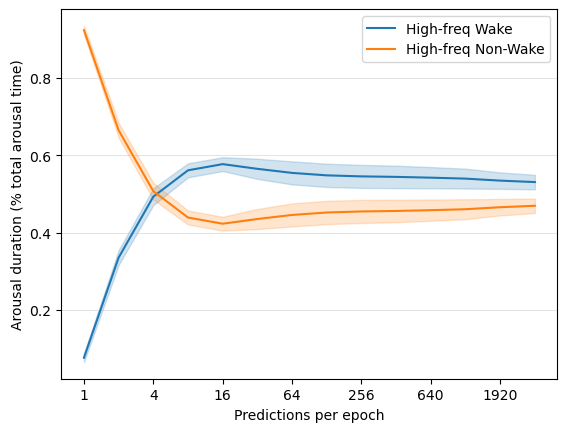

In [4]:
srs = sorted(true_dur_agg_rel.keys())
means = np.array([np.mean([hfdm[sr][0] for hfdm in hf_durs_rel]) for sr in srs])
stds = np.array([np.std([hfdm[sr][0] for hfdm in hf_durs_rel]) for sr in srs])
plt.plot(range(len(srs)), means, label=f"High-freq Wake", color=colors[0])
plt.fill_between(range(len(srs)), means - stds, means + stds, alpha=0.2, color=colors[0])
means = np.array([np.mean([sum([hfdm[sr][i] for i in range(1, 5)]) for hfdm in hf_durs_rel]) for sr in srs])
stds = np.array([np.std([sum([hfdm[sr][i] for i in range(1, 5)]) for hfdm in hf_durs_rel]) for sr in srs])
plt.plot(range(len(srs)), means, label=f"High-freq Non-Wake", color=colors[1])
plt.fill_between(range(len(srs)), means - stds, means + stds, alpha=0.2, color=colors[1])
plt.legend()
plt.xticks(range(0, len(srs), 2), srs[::2])
plt.grid(axis="y")
plt.xlabel("Predictions per epoch")
plt.ylabel("Arousal duration (% total arousal time)")
plt.show()

In [5]:
print(hf_durs_rel)

[{1: array([0.07469559, 0.08570006, 0.59854899, 0.04346803, 0.19758734]), 2: array([0.32234027, 0.06010005, 0.43904538, 0.03558988, 0.14292443]), 4: array([0.48114032, 0.04567315, 0.3347266 , 0.02761894, 0.11084099]), 8: array([0.54966389, 0.04240595, 0.2821733 , 0.02398528, 0.10177158]), 16: array([0.56150251, 0.04687405, 0.26539091, 0.02243686, 0.10379567]), 32: array([0.53620749, 0.05525554, 0.27285269, 0.02380738, 0.11187691]), 64: array([0.52022376, 0.06347607, 0.27035681, 0.02739346, 0.11854989]), 128: array([0.51291263, 0.07024809, 0.26390662, 0.03003688, 0.12289578]), 256: array([0.51007988, 0.07595877, 0.25883415, 0.03119919, 0.123928  ]), 384: array([0.50973826, 0.07808468, 0.25580101, 0.03189067, 0.12448538]), 640: array([0.50988814, 0.08046872, 0.25293435, 0.0320549 , 0.12465389]), 960: array([0.50979388, 0.08201298, 0.25095589, 0.03244238, 0.12479486]), 1920: array([0.5092426 , 0.08364129, 0.24874115, 0.03334658, 0.12502837]), 3840: array([0.50848272, 0.08533708, 0.2473167